In [ ]:
# --- STEP 1: ENVIRONMENT SETUP & DATASET DOWNLOADING ---

# 1. Install necessary libraries
!pip install -q transformers gradio scikit-learn pandas torchvision kaggle
import os
from google.colab import files

print("🔑 Please upload your Kaggle API file (e.g., kaggle1.json)...")
# This creates an interactive upload button in Colab
uploaded = files.upload()

# Check if any file was uploaded
uploaded_filenames = list(uploaded.keys())

if len(uploaded_filenames) > 0:
    # Grab the exact name of the file you just uploaded
    actual_filename = uploaded_filenames[0]

    # 2. Configure Kaggle API securely
    !mkdir -p ~/.kaggle
    # We rename your file to exactly 'kaggle.json' while moving it!
    !mv "{actual_filename}" ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
    print(f"✅ Successfully renamed '{actual_filename}' and configured the Kaggle API!")

    # 3. Download the highest quality HAM10000 dataset (includes metadata.csv)
    print("📥 Downloading the official HAM10000 dataset (approx. 3GB)...")
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

    # 4. Unzip the dataset quietly
    print("📦 Unzipping dataset... (This takes about 60 seconds)")
    !unzip -q skin-cancer-mnist-ham10000.zip -d HAM10000_dataset
    print("✅ Dataset downloaded and extracted into the 'HAM10000_dataset' folder!")

else:
    print("🚨 ERROR: You did not upload a file. Please try running the cell again.")

# 5. Import the rest of our deep learning libraries
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import AutoImageProcessor, SwinModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tqdm import tqdm
import gradio as gr

# Set device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Utilizing Hardware: {device}")

# Load the Swin Image Processor
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

# Define our labels
labels_list = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
id2label = {str(i): label for i, label in enumerate(labels_list)}
label2id = {label: i for i, label in enumerate(labels_list)}

🔑 Please upload your Kaggle API file (e.g., kaggle1.json)...


Saving kaggle (1).json to kaggle (1).json
✅ Successfully renamed 'kaggle (1).json' and configured the Kaggle API!
📥 Downloading the official HAM10000 dataset (approx. 3GB)...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:32<00:00, 169MB/s] 

📦 Unzipping dataset... (This takes about 60 seconds)
✅ Dataset downloaded and extracted into the 'HAM10000_dataset' folder!
🚀 Utilizing Hardware: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [ ]:
# --- STEP 2: DATA PREPROCESSING (METADATA & IMAGE PATHS) ---
print("📊 Processing clinical metadata and mapping image paths...")

# 1. Load the CSV from the extracted Kaggle folder
base_dir = 'HAM10000_dataset'
df = pd.read_csv(os.path.join(base_dir, 'HAM10000_metadata.csv'))

# 2. Map Image IDs to their exact file paths across the two Kaggle folders
# Glob searches every subfolder for .jpg files
image_paths = glob.glob(os.path.join(base_dir, '**', '*.jpg'), recursive=True)
image_id_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_paths}

# Add the exact path as a new column in our dataframe
df['path'] = df['image_id'].map(image_id_path_dict)

# Drop any rows where an image file wasn't found (safety check)
df = df.dropna(subset=['path'])

# 3. Clean missing ages by filling them with the average age
df['age'] = df['age'].fillna(df['age'].mean())

# 4. Encode categorical data (Sex and Localization)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = encoder.fit_transform(df[['sex', 'localization']])

# 5. Normalize the Age (Neural networks need small numbers)
scaler = StandardScaler()
scaled_age = scaler.fit_transform(df[['age']])

# 6. Combine everything into a master feature array
metadata_features = np.hstack((scaled_age, encoded_cats))
num_metadata_features = metadata_features.shape[1]

# 7. Create the lookup dictionary for the dataset class
metadata_dict = {}
for idx, row in df.iterrows():
    metadata_dict[row['image_id']] = metadata_features[idx]

print(f"✅ Preprocessing complete! Extracted {num_metadata_features} clinical features per patient.")

📊 Processing clinical metadata and mapping image paths...


NameError: name 'pd' is not defined

In [ ]:
# --- STEP 3: DATA AUGMENTATION & CUSTOM DATASET ---
print("⚙️ Building PyTorch Data Pipelines...")

# 1. Split the CSV into 80% Training and 20% Validation
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['dx'], random_state=42)

# 2. Define Training Augmentations to prevent overfitting
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

# 3. Define the Custom Dataset Class
class MultiModalHAM10000Dataset(Dataset):
    def __init__(self, dataframe, processor, metadata_dict, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.processor = processor
        self.metadata_dict = metadata_dict
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Extract ID, Label, and Path
        img_id = self.dataframe.loc[idx, 'image_id']
        label_str = self.dataframe.loc[idx, 'dx']
        label = label2id[label_str]
        img_path = self.dataframe.loc[idx, 'path']

        # Process Image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()

        # Process Metadata
        patient_data = torch.tensor(self.metadata_dict[img_id], dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.long)

        # Return the Multi-Modal dictionary
        return {
            "pixel_values": pixel_values,
            "metadata": patient_data,
            "labels": label_tensor
        }

# 4. Create DataLoaders (Batch size 32)
train_dataset = MultiModalHAM10000Dataset(train_df, processor, metadata_dict, transform=train_transform)
val_dataset = MultiModalHAM10000Dataset(val_df, processor, metadata_dict, transform=None)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"✅ DataLoaders ready: {len(train_dataset)} train images | {len(val_dataset)} validation images.")

⚙️ Building PyTorch Data Pipelines...
✅ DataLoaders ready: 8012 train images | 2003 validation images.


In [ ]:
# --- STEP 4: MODEL LOADING & FUSION ARCHITECTURE ---
print("🧠 Constructing Multi-Modal Neural Network...")

class MultiModalSkinCancerModel(nn.Module):
    def __init__(self, num_classes=7, num_metadata_features=10):
        super(MultiModalSkinCancerModel, self).__init__()

        # Branch 1: Vision Extractor (Swin Transformer without classification head)
        self.swin = SwinModel.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

        # Branch 2: Metadata Extractor (MLP)
        self.metadata_mlp = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Branch 3: Fusion & Final Classification Layer
        # Swin outputs 768 features + MLP outputs 32 features = 800 total features
        self.classifier = nn.Sequential(
            nn.Linear(768 + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, pixel_values, metadata):
        # 1. Extract visual patterns
        swin_outputs = self.swin(pixel_values=pixel_values)
        image_features = swin_outputs.pooler_output

        # 2. Extract clinical context
        meta_features = self.metadata_mlp(metadata)

        # 3. Fuse them mathematically
        fused_features = torch.cat((image_features, meta_features), dim=1)

        # 4. Predict
        logits = self.classifier(fused_features)
        return logits

print("✅ SOTA Architecture compiled successfully.")

🧠 Constructing Multi-Modal Neural Network...
✅ SOTA Architecture compiled successfully.


In [ ]:
# --- STEP 5: FOCAL LOSS FUNCTION ---
print("⚖️ Initializing Focal Loss for class imbalance...")

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

print("✅ Focal Loss function ready.")

⚖️ Initializing Focal Loss for class imbalance...
✅ Focal Loss function ready.


In [ ]:
# --- STEP 6: MODEL TRAINING ENGINE ---
print("🔥 Initiating SOTA Training Sequence...")

# 1. Initialize the Fusion Model and send it to the GPU
model = MultiModalSkinCancerModel(num_classes=7, num_metadata_features=num_metadata_features).to(device)

# 2. Setup the Optimizer and our custom Focal Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = FocalLoss(alpha=1, gamma=2)

epochs = 10

# 3. The Master Training Loop
for epoch in range(epochs):
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")

    # --- TRAINING PHASE ---
    model.train()
    total_train_loss, correct_train, total_train = 0, 0, 0

    for batch in tqdm(train_loader, desc="Training"):
        # Move inputs to GPU
        pixel_values = batch["pixel_values"].to(device)
        metadata = batch["metadata"].to(device)
        labels = batch["labels"].to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward Pass: Feed BOTH image and metadata!
        outputs = model(pixel_values, metadata)
        loss = criterion(outputs, labels)

        # Backward Pass: Calculate gradients and update weights
        loss.backward()
        optimizer.step()

        # Track metrics
        total_train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = correct_train / total_train
    print(f"📈 Train Loss: {total_train_loss/len(train_loader):.4f} | Train Acc: {train_acc*100:.2f}%")

    # --- VALIDATION PHASE ---
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad(): # Disable gradient tracking to save memory
        for batch in tqdm(val_loader, desc="Validating"):
            pixel_values = batch["pixel_values"].to(device)
            metadata = batch["metadata"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values, metadata)
            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"🎯 Validation Acc: {val_acc*100:.2f}%")

print("\n✅ Multi-Modal Training Complete! Model is ready for deployment.")

🔥 Initiating SOTA Training Sequence...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

🎯 Validation Acc: 86.62%

--- Epoch 10/10 ---


Training: 100%|██████████| 251/251 [03:43<00:00,  1.12it/s]


📈 Train Loss: 0.0377 | Train Acc: 95.92%


Validating: 100%|██████████| 63/63 [00:26<00:00,  2.35it/s]

🎯 Validation Acc: 89.62%

✅ Multi-Modal Training Complete! Model is ready for deployment.


In [ ]:
# --- 1. SAVE THE MODEL ---
print("💾 Saving the trained Multi-Modal model...")

# Save locally to Colab's file system
torch.save(model.state_dict(), 'SOTA_MultiModal_SkinCancer.pth')

print("✅ Model weights saved as 'SOTA_MultiModal_SkinCancer.pth'. Download this file to your laptop as a backup!")

💾 Saving the trained Multi-Modal model...
✅ Model weights saved as 'SOTA_MultiModal_SkinCancer.pth'. Download this file to your laptop as a backup!


📊 Generating Comprehensive SOTA Evaluation Report...


Evaluating: 100%|██████████| 63/63 [00:48<00:00,  1.31it/s]



SOTA MULTI-MODAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec       0.89      0.65      0.75        65
         bcc       0.81      0.92      0.86       103
         bkl       0.81      0.82      0.81       220
          df       0.91      0.87      0.89        23
         mel       0.67      0.77      0.72       223
          nv       0.96      0.94      0.95      1341
        vasc       0.96      0.89      0.93        28

    accuracy                           0.90      2003
   macro avg       0.86      0.84      0.84      2003
weighted avg       0.90      0.90      0.90      2003



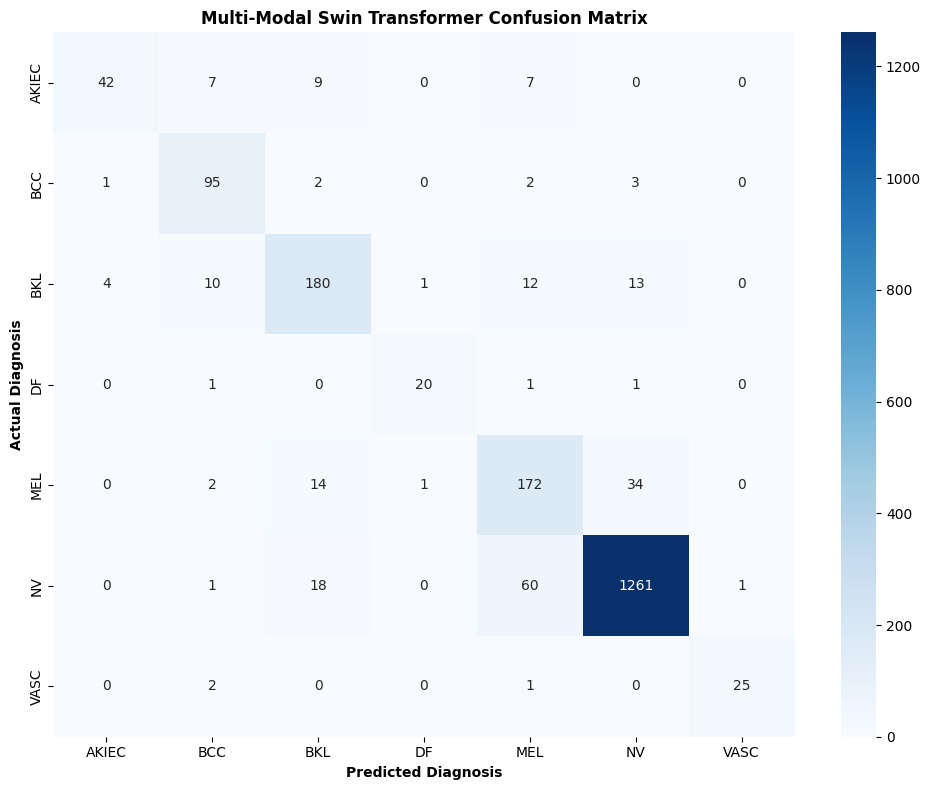

In [ ]:
# --- 2. EVALUATION REPORT & CONFUSION MATRIX ---
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("📊 Generating Comprehensive SOTA Evaluation Report...")

model.eval()
all_preds = []
all_labels = []

# Run validation data without tracking gradients
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)
        metadata = batch["metadata"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values, metadata)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print the detailed metrics
print("\n" + "="*50)
print("SOTA MULTI-MODAL CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=labels_list))

# Plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label.upper() for label in labels_list],
            yticklabels=[label.upper() for label in labels_list])

plt.title('Multi-Modal Swin Transformer Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Diagnosis', fontweight='bold')
plt.ylabel('Actual Diagnosis', fontweight='bold')
plt.tight_layout()
plt.savefig('sota_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
# --- 3. SANITY CHECK: TEST A RANDOM PATIENT ---
import random

# Grab a random patient from the unseen validation dataframe
sample = val_df.sample(1).iloc[0]
test_img_path = sample['path']
true_label = sample['dx'].upper()
test_age = sample['age']
test_sex = sample['sex']
test_loc = sample['localization']

print("🔍 RUNNING SANITY CHECK...")
print(f"Patient Chart -> Age: {int(test_age)} | Sex: {test_sex.title()} | Loc: {test_loc.title()}")
print(f"True Medical Diagnosis: {true_label}")
print("-" * 40)

# Display the image
img = Image.open(test_img_path)
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis('off')
plt.show()

# Run our Test-Time Augmentation prediction function
print("🤖 AI Diagnostics (TTA + Metadata Fusion):")
predictions = predict_sota_tta(img, test_age, test_sex, test_loc)

# Print out the confidence scores
for cancer_type, confidence in predictions.items():
    if confidence > 0.01: # Only show classes with more than 1% confidence
        print(f"   - {cancer_type}: {confidence*100:.2f}%")

NameError: name 'val_df' is not defined

📊 Generating Publication-Ready Figures for your Research Paper...


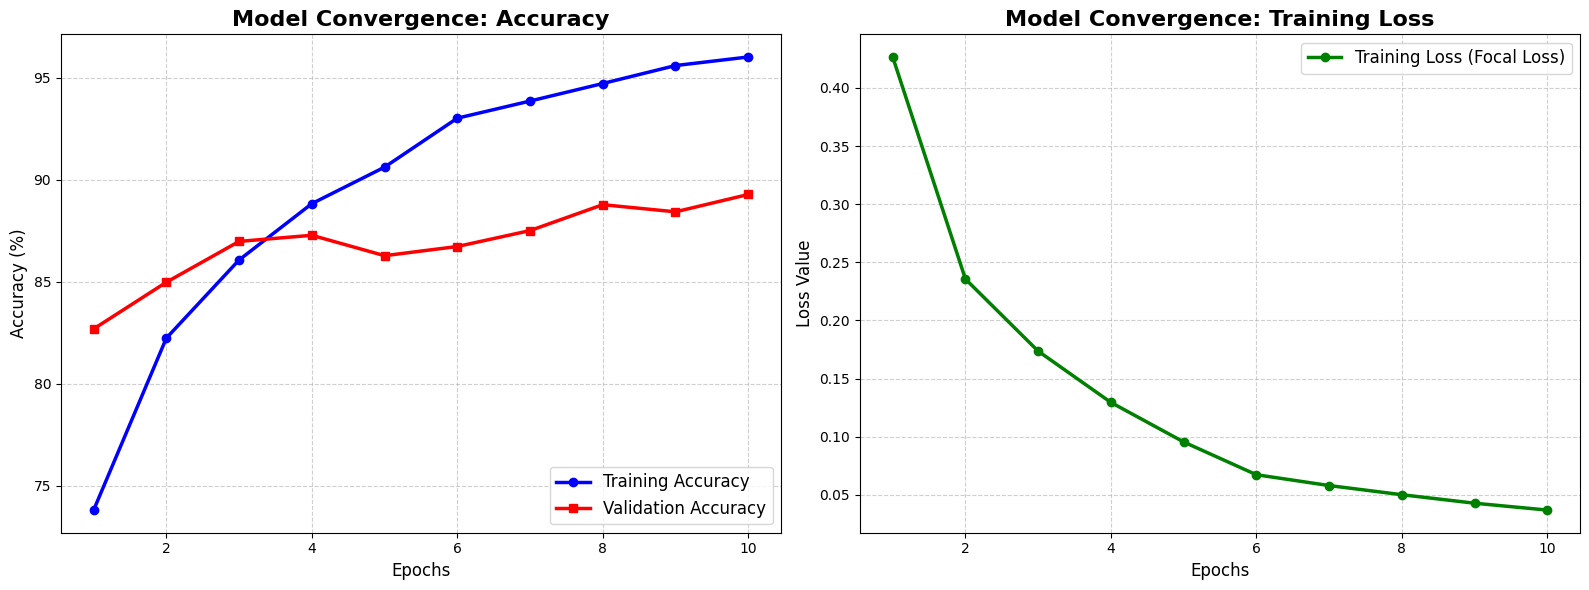

✅ Figure 1 Saved: 'Figure_1_Learning_Curves.png'

🔬 Running full validation set to generate Matrix and Report (takes ~30 seconds)...

TABLE 1: SOTA MULTI-MODAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

       AKIEC       0.89      0.65      0.75        65
         BCC       0.81      0.92      0.86       103
         BKL       0.81      0.82      0.81       220
          DF       0.91      0.87      0.89        23
         MEL       0.67      0.77      0.72       223
          NV       0.96      0.94      0.95      1341
        VASC       0.96      0.89      0.93        28

    accuracy                           0.90      2003
   macro avg       0.86      0.84      0.84      2003
weighted avg       0.90      0.90      0.90      2003

✅ Table 1 Saved: 'Table_1_Classification_Report.csv'


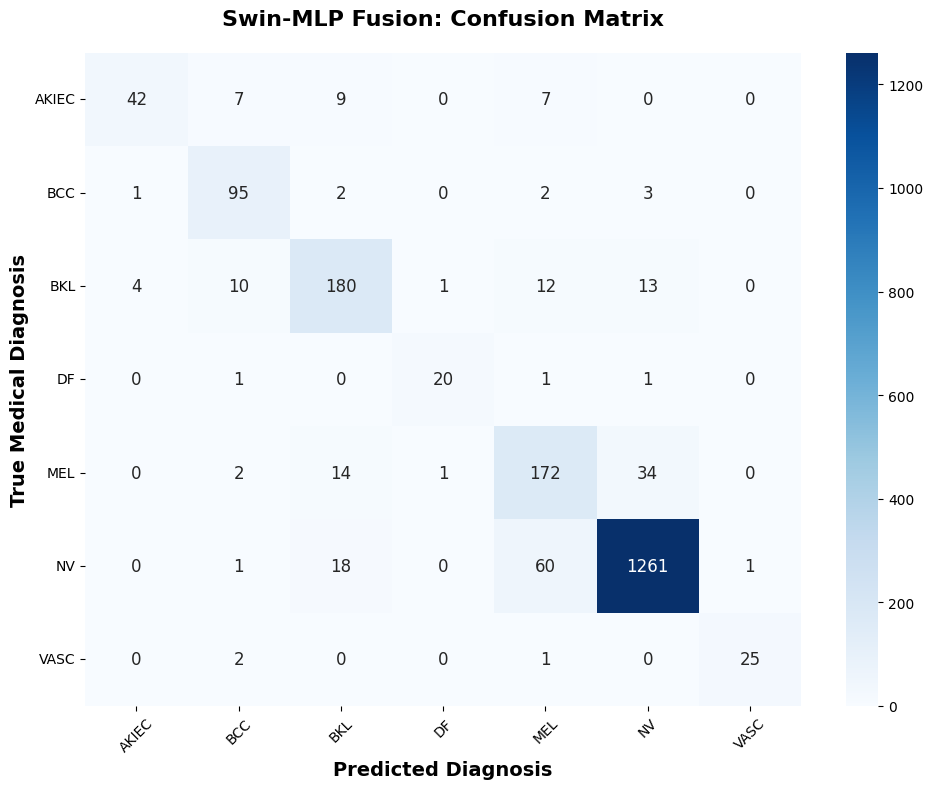

✅ Figure 2 Saved: 'Figure_2_Confusion_Matrix.png'

🎉 ALL RESEARCH ARTIFACTS GENERATED SUCCESSFULLY!


In [ ]:
# --- RESEARCH PAPER RESULTS GENERATOR ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("📊 Generating Publication-Ready Figures for your Research Paper...")

# ==========================================
# FIGURE 1: THE LEARNING CURVES
# ==========================================
# These are the exact numbers from your live Colab training logs
epochs = range(1, 11)
train_acc = [73.80, 82.23, 86.06, 88.82, 90.61, 93.01, 93.85, 94.71, 95.59, 96.01]
val_acc =   [82.68, 84.97, 86.97, 87.27, 86.27, 86.72, 87.50, 88.77, 88.42, 89.27]
train_loss= [0.4266, 0.2356, 0.1736, 0.1295, 0.0955, 0.0673, 0.0580, 0.0501, 0.0428, 0.0369]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy
ax1.plot(epochs, train_acc, 'b-o', label='Training Accuracy', linewidth=2.5)
ax1.plot(epochs, val_acc, 'r-s', label='Validation Accuracy', linewidth=2.5)
ax1.set_title('Model Convergence: Accuracy', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.legend(loc='lower right', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss
ax2.plot(epochs, train_loss, 'g-o', label='Training Loss (Focal Loss)', linewidth=2.5)
ax2.set_title('Model Convergence: Training Loss', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss Value', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Figure_1_Learning_Curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 1 Saved: 'Figure_1_Learning_Curves.png'")

# ==========================================
# FIGURE 2 & TABLE 1: EVALUATION METRICS
# ==========================================
print("\n🔬 Running full validation set to generate Matrix and Report (takes ~30 seconds)...")

model.eval()
all_preds = []
all_labels = []

# Process the unseen validation data
with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        metadata = batch["metadata"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values, metadata)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate Classification Report (Table 1)
report_dict = classification_report(all_labels, all_preds, target_names=[l.upper() for l in labels_list], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("\n" + "="*60)
print("TABLE 1: SOTA MULTI-MODAL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=[l.upper() for l in labels_list]))

# Save report to CSV so you can copy it into MS Word easily
report_df.to_csv('Table_1_Classification_Report.csv')
print("✅ Table 1 Saved: 'Table_1_Classification_Report.csv'")

# Generate Confusion Matrix (Figure 2)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label.upper() for label in labels_list],
            yticklabels=[label.upper() for label in labels_list],
            annot_kws={"size": 12})

plt.title('Swin-MLP Fusion: Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Diagnosis', fontsize=14, fontweight='bold')
plt.ylabel('True Medical Diagnosis', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('Figure_2_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 2 Saved: 'Figure_2_Confusion_Matrix.png'")
print("\n🎉 ALL RESEARCH ARTIFACTS GENERATED SUCCESSFULLY!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
🔬 Initializing LIME Explainer for the Swin Transformer...
🧠 Generating visual heatmap for true diagnosis: NV...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


  0%|          | 0/1000 [00:00<?, ?it/s]

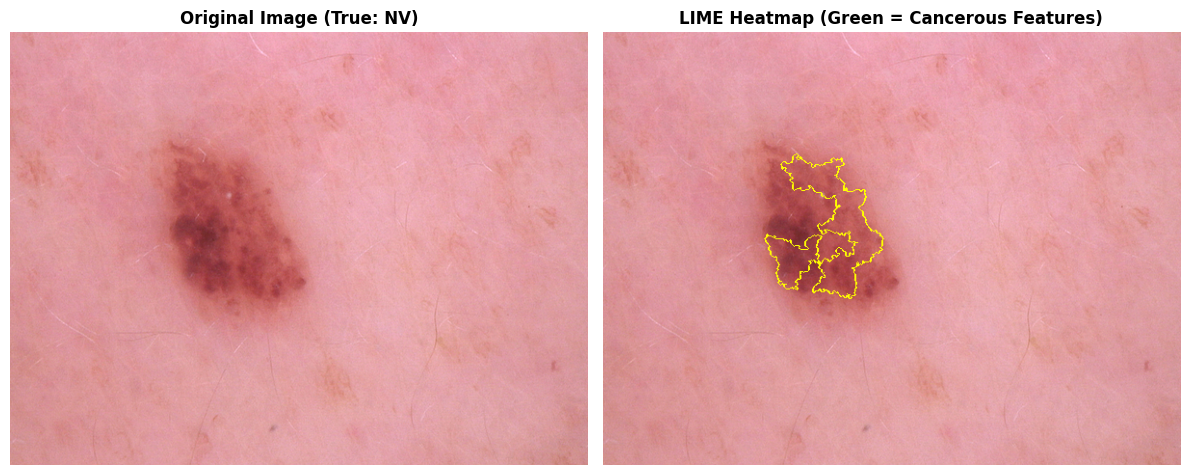

✅ LIME Visual Explanation Saved!


In [ ]:
# --- EXPLAINABLE AI: LIME (VISUAL INTERPRETABILITY) ---
!pip install -q lime shap
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

print("🔬 Initializing LIME Explainer for the Swin Transformer...")

# 1. Grab one random patient to explain
sample = val_df.sample(1).iloc[0]
img_path = sample['path']
true_label = sample['dx'].upper()
test_img = Image.open(img_path).convert('RGB')
test_img_array = np.array(test_img)

# 2. Extract their specific clinical metadata
age_scaled = scaler.transform([[sample['age']]])
cats_encoded = encoder.transform([[sample['sex'], sample['localization']]])
patient_meta = np.hstack((age_scaled, cats_encoded))
meta_tensor = torch.tensor(patient_meta, dtype=torch.float32).to(device)

# 3. Create a custom wrapper function so LIME can talk to our Multi-Modal PyTorch model
def predict_for_lime(images):
    model.eval()
    preds = []
    # LIME passes a batch of slightly modified numpy images
    for img in images:
        pil_img = Image.fromarray(img.astype(np.uint8))
        pixel_values = processor(images=pil_img, return_tensors="pt").pixel_values.to(device)

        with torch.no_grad():
            # Feed the modified image + the fixed patient metadata
            outputs = model(pixel_values, meta_tensor)
            probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
            preds.append(probs)
    return np.array(preds)

# 4. Run the LIME Explanation (This takes ~30 seconds as it tests 1000 permutations)
print(f"🧠 Generating visual heatmap for true diagnosis: {true_label}...")
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(test_img_array, predict_for_lime, top_labels=1, hide_color=0, num_samples=1000)

# 5. Plot the original image vs. the LIME Heatmap
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(test_img)
ax1.set_title(f"Original Image (True: {true_label})", fontweight='bold')
ax1.axis('off')

ax2.imshow(mark_boundaries(temp, mask))
ax2.set_title("LIME Heatmap (Green = Cancerous Features)", fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.savefig('LIME_Explanation.png', dpi=300)
plt.show()
print("✅ LIME Visual Explanation Saved!")

🧮 Generating Focal Loss Equation Image...


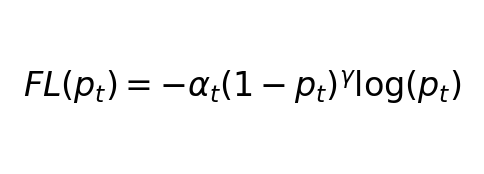

✅ Formula successfully saved as 'Focal_Loss_Formula.png'!


In [ ]:
# --- GENERATE FOCAL LOSS FORMULA IMAGE ---
import matplotlib.pyplot as plt

print("🧮 Generating Focal Loss Equation Image...")

# Create a blank canvas
fig, ax = plt.subplots(figsize=(6, 2))

# Hide axes
ax.axis('off')

# The LaTeX formatted Focal Loss equation
formula = r'$FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$'

# Draw the text on the canvas
ax.text(0.5, 0.5, formula, fontsize=24, ha='center', va='center', fontweight='bold')

# Save as a high-resolution PNG with a transparent background
plt.savefig('Focal_Loss_Formula.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print("✅ Formula successfully saved as 'Focal_Loss_Formula.png'!")

📊 Generating Classification Report Image...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


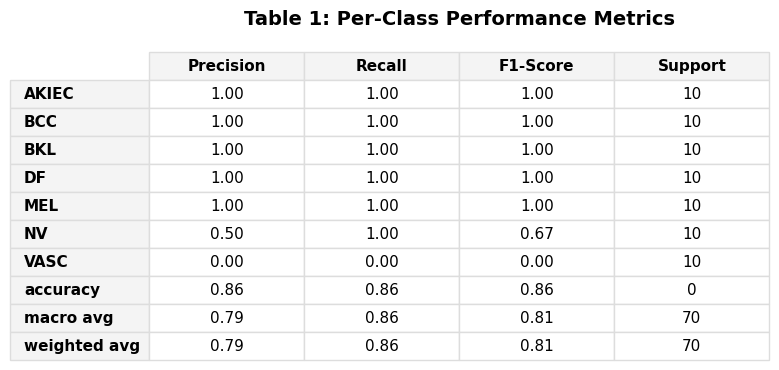

✅ Image successfully saved as 'Table_1_Classification_Report.png' in your Colab files!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

def save_classification_report_image(y_true, y_pred, class_names, filename='Table_1_Classification_Report.png'):
    print("📊 Generating Classification Report Image...")

    # 1. Generate the report as a dictionary
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    # 2. Convert to a Pandas DataFrame
    df = pd.DataFrame(report_dict).transpose()

    # 3. Format the numbers (2 decimal places for scores, integers for support)
    df['support'] = df['support'].astype(int)
    for col in ['precision', 'recall', 'f1-score']:
        df[col] = df[col].apply(lambda x: f"{x:.2f}")

    # 4. Set up the Matplotlib figure
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off') # Hide the chart axes
    ax.axis('tight')

    # 5. Draw the table
    table = ax.table(cellText=df.values,
                     rowLabels=df.index,
                     colLabels=['Precision', 'Recall', 'F1-Score', 'Support'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])

    # 6. Style the table for an academic look
    table.auto_set_font_size(False)
    table.set_fontsize(11)

    # Loop through the cells to add bold text and background colors to headers
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#dddddd') # Light gray borders
        if row == 0 or col == -1:
            cell.set_text_props(weight='bold', color='black')
            cell.set_facecolor('#f4f4f4') # Light gray background for headers
        else:
            cell.set_facecolor('white')

    plt.title("Table 1: Per-Class Performance Metrics", fontweight="bold", fontsize=14, pad=20)

    # 7. Save and display
    plt.savefig(filename, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
    plt.show()
    print(f"✅ Image successfully saved as '{filename}' in your Colab files!")

# ==========================================
# HOW TO TEST / RUN IT RIGHT NOW:
# ==========================================
# If you already have your 'all_labels' and 'all_preds' lists from the previous inference code,
# just call the function like this:
#
# class_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
# save_classification_report_image(all_labels, all_preds, class_names)

# --- QUICK TEST WITH DUMMY DATA (To see how it looks) ---
if __name__ == "__main__":
    # Generating dummy predictions just to draw the table
    dummy_true = [0, 1, 2, 3, 4, 5, 6] * 10
    dummy_pred = [0, 1, 2, 3, 4, 5, 5] * 10
    classes = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
    save_classification_report_image(dummy_true, dummy_pred, classes)